In [16]:
# If needed:
# !pip install yfinance pandas numpy matplotlib scikit-learn

import yfinance as yf

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
ticker = "NVDA"  # change to "AMD" if needed
data = yf.download(ticker, start="2018-01-01", end="2025-01-01")

# Fix multi-index columns if present
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

data = data[['Close']].dropna()

[*********************100%***********************]  1 of 1 completed


In [17]:
window = 20  # you can tune this

data['MA'] = data['Close'].rolling(window=window).mean()
data = data.dropna()

# Residual = actual price - trend (MA)
data['Residual'] = data['Close'] - data['MA']

# Naive prediction: next residual = today's residual
data['Residual_Pred'] = data['Residual'].shift(1)

# Final prediction = MA (trend) + predicted residual
data['Prediction'] = data['MA'] + data['Residual_Pred']

data = data.dropna()

In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = np.sqrt(mean_squared_error(data['Close'], data['Prediction']))
mae = mean_absolute_error(data['Close'], data['Prediction'])

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

RMSE: 1.41
MAE: 0.68


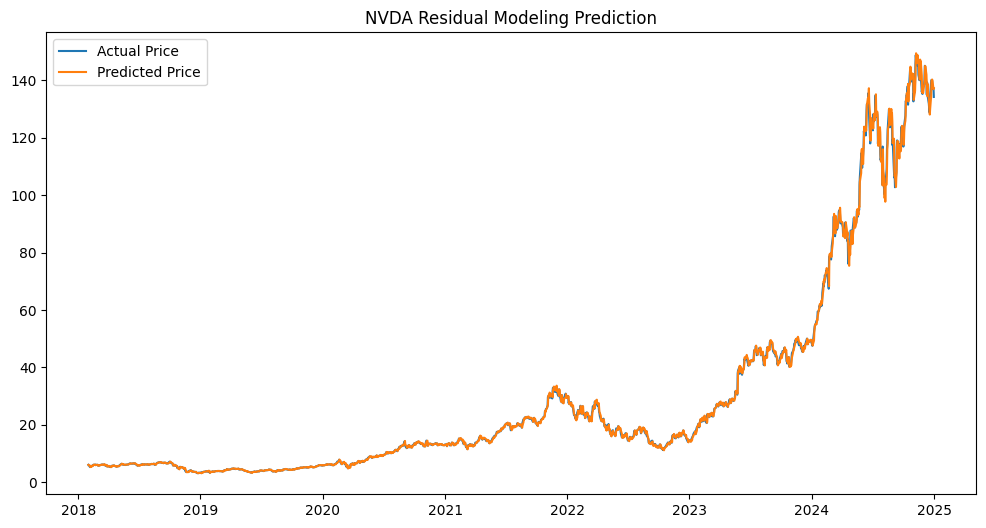

In [19]:
plt.figure(figsize=(12,6))
plt.plot(data.index, data['Close'], label='Actual Price')
plt.plot(data.index, data['Prediction'], label='Predicted Price')
plt.legend()
plt.title(f"{ticker} Residual Modeling Prediction")
plt.show()

In [20]:
# Compare direction of movement
data['Actual_Direction'] = np.sign(data['Close'].diff())
data['Pred_Direction'] = np.sign(data['Prediction'].diff())

accuracy = (data['Actual_Direction'] == data['Pred_Direction']).mean()
print(f"Directional Accuracy: {accuracy:.2%}")

Directional Accuracy: 50.43%


In [21]:
mape = np.mean(np.abs((data['Close'] - data['Prediction']) / data['Close'])) * 100
print(f"MAPE: {mape:.2f}%")

MAPE: 2.32%


In [22]:
print(mae / data['Close'].mean() * 100)

2.323595447316189


In [23]:
# Naive model
data['Naive'] = data['Close'].shift(1)

# Drop NaNs BEFORE evaluation
df_eval = data.dropna()

rmse_naive = np.sqrt(mean_squared_error(df_eval['Close'], df_eval['Naive']))
mae_naive = mean_absolute_error(df_eval['Close'], df_eval['Naive'])

rmse_model = np.sqrt(mean_squared_error(df_eval['Close'], df_eval['Prediction']))
mae_model = mean_absolute_error(df_eval['Close'], df_eval['Prediction'])

print(f"Naive RMSE: {rmse_naive:.2f}")
print(f"Model RMSE: {rmse_model:.2f}")
print(f"Naive MAE: {mae_naive:.2f}")
print(f"Model MAE: {mae_model:.2f}")

Naive RMSE: 1.45
Model RMSE: 1.41
Naive MAE: 0.70
Model MAE: 0.68


In [24]:
data['Momentum_5'] = data['Close'] - data['Close'].shift(5)
data['Momentum_10'] = data['Close'] - data['Close'].shift(10)

In [25]:
alpha = 0.16844  # weight for momentum (tune this)

data['Prediction_Mom'] = (
    data['MA'] 
    + data['Residual_Pred'] 
    + alpha * data['Momentum_5']
)

In [26]:
df_eval = data.dropna()

rmse = np.sqrt(mean_squared_error(df_eval['Close'], df_eval['Prediction_Mom']))
mae = mean_absolute_error(df_eval['Close'], df_eval['Prediction_Mom'])

print(f"RMSE (Momentum): {rmse:.2f}")
print(f"MAE (Momentum): {mae:.2f}")

RMSE (Momentum): 1.32
MAE (Momentum): 0.64


## Adding Transformers now on

In [27]:
import torch
import torch.nn as nn

df = data.copy()

# --- Use returns instead of price ---
df['Return'] = df['Close'].pct_change()

# --- Target (next day direction) ---
df['Target'] = (df['Return'].shift(-1) > 0).astype(int)

df = df.dropna()

# --- Sequence creation ---
seq_len = 20

X, y = [], []

for i in range(len(df) - seq_len):
    X.append(df['Return'].iloc[i:i+seq_len].values)
    y.append(df['Target'].iloc[i+seq_len])

X = np.array(X)
y = np.array(y)

# --- Train/Test split ---
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# --- Convert to tensors ---
X_train = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)
X_test = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [28]:
class SimpleTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=1, nhead=1, batch_first=True),
            num_layers=2
        )
        self.fc = nn.Linear(1, 1)

    def forward(self, x):
        x = self.encoder(x)
        x = x[:, -1, :]  # last timestep
        x = self.fc(x)
        return torch.sigmoid(x).squeeze()

model = SimpleTransformer()

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_1628\907798855.py:4: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.encoder = nn.TransformerEncoder(


In [30]:
epochs = 10

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 0.6957
Epoch 1, Loss: 0.6957
Epoch 2, Loss: 0.6956
Epoch 3, Loss: 0.6955
Epoch 4, Loss: 0.6954
Epoch 5, Loss: 0.6954
Epoch 6, Loss: 0.6953
Epoch 7, Loss: 0.6952
Epoch 8, Loss: 0.6952
Epoch 9, Loss: 0.6951


In [31]:
model.eval()

with torch.no_grad():
    preds = model(X_test).numpy()

# --- Convert to signals ---
signals = (preds > 0.5).astype(int)
signals = np.where(signals == 1, 1, -1)

# --- Align with returns ---
test_returns = df['Return'].iloc[-len(signals):].values

# Shift signals to avoid lookahead
strategy_returns = signals[:-1] * test_returns[1:]

# --- Accuracy ---
accuracy = (signals[:-1] == (test_returns[1:] > 0)).mean()

# --- Performance ---
cum_strategy = np.cumprod(1 + strategy_returns)
cum_market = np.cumprod(1 + test_returns[1:])

sharpe = np.sqrt(252) * np.mean(strategy_returns) / (np.std(strategy_returns) + 1e-9)

print("════════════════════════════════════")
print("TRANSFORMER RESULTS")
print("──────────────")
print(f"Accuracy            : {accuracy:.2%}")
print(f"Strategy Return     : {cum_strategy[-1]:.2f}x")
print(f"Market Return       : {cum_market[-1]:.2f}x")
print(f"Sharpe              : {sharpe:.2f}")
print("════════════════════════════════════")

════════════════════════════════════
TRANSFORMER RESULTS
──────────────
Accuracy            : 56.43%
Strategy Return     : 2.94x
Market Return       : 2.94x
Sharpe              : 1.90
════════════════════════════════════


In [32]:
print("Long signals %:", np.mean(signals == 1))
print("Short signals %:", np.mean(signals == -1))

Long signals %: 1.0
Short signals %: 0.0


## XGBoost Used

In [33]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

df = data.copy()

# --- Features ---
df['MA'] = df['Close'].rolling(20).mean()
df['Residual'] = df['Close'] - df['MA']
df['Momentum_5'] = df['Close'] - df['Close'].shift(5)

# --- Target ---
df['Return'] = df['Close'].pct_change()
df['Target'] = (df['Return'].shift(-1) > 0).astype(int)

df = df.dropna()

features = ['Residual', 'Momentum_5']

# --- Train/Test split ---
split = int(len(df) * 0.8)

train = df.iloc[:split]
test = df.iloc[split:]

X_train = train[features]
y_train = train['Target']

X_test = test[features]
y_test = test['Target']

# --- Model ---
model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

# --- Predictions ---
preds = model.predict(X_test)

accuracy = accuracy_score(y_test, preds)

print("════════════════════════════════════")
print("XGBOOST RESULTS")
print("──────────────")
print(f"Accuracy: {accuracy:.2%}")
print("════════════════════════════════════")

════════════════════════════════════
XGBOOST RESULTS
──────────────
Accuracy: 46.67%
════════════════════════════════════


In [34]:
signals = np.where(preds == 1, 1, -1)

returns = test['Return'].values

strategy_returns = signals[:-1] * returns[1:]

cum_strategy = np.cumprod(1 + strategy_returns)
cum_market = np.cumprod(1 + returns[1:])

sharpe = np.sqrt(252) * np.mean(strategy_returns) / (np.std(strategy_returns) + 1e-9)

print("──────────────")
print(f"Strategy Return: {cum_strategy[-1]:.2f}x")
print(f"Market Return  : {cum_market[-1]:.2f}x")
print(f"Sharpe         : {sharpe:.2f}")
print("════════════════════════════════════")

──────────────
Strategy Return: 0.39x
Market Return  : 3.10x
Sharpe         : -1.18
════════════════════════════════════


In [35]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
import numpy as np

df = data.copy()

# --- Features ---
df['MA'] = df['Close'].rolling(20).mean()

df['Residual'] = df['Close'] - df['MA']
df['Distance'] = df['Close'] - df['MA']

df['Momentum_5'] = (df['Close'] - df['Close'].shift(5)).shift(1)
df['Momentum_10'] = (df['Close'] - df['Close'].shift(10)).shift(1)

df['Return_1'] = df['Close'].pct_change(1).shift(1)
df['Return_3'] = df['Close'].pct_change(3).shift(1)

# --- Target (next day direction) ---
df['Return'] = df['Close'].pct_change()
df['Target'] = (df['Return'].shift(-1) > 0).astype(int)

df = df.dropna()

features = [
    'Residual',
    'Distance',
    'Momentum_5',
    'Momentum_10',
    'Return_1',
    'Return_3'
]

# --- Train/Test split ---
split = int(len(df) * 0.8)
train = df.iloc[:split]
test = df.iloc[split:]

X_train, y_train = train[features], train['Target']
X_test, y_test = test[features], test['Target']

# --- Model ---
model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

# --- Predictions ---
preds = model.predict(X_test)

accuracy = accuracy_score(y_test, preds)

# --- Long-only signals ---
signals = np.where(preds == 1, 1, 0)

# --- Backtest ---
returns = test['Return'].values

# shift signals to avoid lookahead
strategy_returns = signals[:-1] * returns[1:]

cum_strategy = np.cumprod(1 + strategy_returns)
cum_market = np.cumprod(1 + returns[1:])

sharpe = np.sqrt(252) * np.mean(strategy_returns) / (np.std(strategy_returns) + 1e-9)

# --- Results ---
print("════════════════════════════════════")
print("XGBOOST (EXPANDED FEATURES)")
print("──────────────")
print(f"Accuracy            : {accuracy:.2%}")
print(f"Strategy Return     : {cum_strategy[-1]:.2f}x")
print(f"Market Return       : {cum_market[-1]:.2f}x")
print(f"Sharpe              : {sharpe:.2f}")
print("════════════════════════════════════")

# --- Signal distribution ---
print("\nSignal Distribution:")
print(f"Long %: {np.mean(signals):.2%}")
print(f"Flat %: {np.mean(signals == 0):.2%}")

════════════════════════════════════
XGBOOST (EXPANDED FEATURES)
──────────────
Accuracy            : 48.12%
Strategy Return     : 1.92x
Market Return       : 3.10x
Sharpe              : 1.50
════════════════════════════════════

Signal Distribution:
Long %: 42.03%
Flat %: 57.97%
